# 🌊 JalRakshak Health AI - Multi-Dimensional Outbreak Risk Prediction & 15-Model Leaderboard

Welcome to the advanced, real-world epidemiological machine learning pipeline for **JalRakshak Health AI – Smart Health Surveillance & Disease Early Warning System**.

In this notebook, we integrate clinical, environmental, temporal, and location dimensions to predict rural waterborne outbreak risks with maximum precision. Instead of synthetic mock features, we ingest real datasets unzipped from Kaggle to build a highly realistic pipeline. To achieve high epidemiological fidelity, we filter clinical symptoms to focus exclusively on rural and flood-prone waterborne and vector-borne epidemic diseases (Typhoid, Gastroenteritis/Cholera, Malaria, Dengue, Jaundice, Hepatitis A, and Hepatitis E), discarding all unrelated external conditions.

### 📋 Integrated Datasets (Kaggle)
1. **Symptoms Dataset**: `itachi9604/disease-symptom-description-dataset` (Real mapped patient symptoms)
2. **Rainfall Dataset**: `rajanand/rainfall-in-india` (Real monthly and annual rainfall records from 1901-2015)
3. **EM-DAT Natural Disasters Dataset**: `brsdincer/all-natural-disasters-19002021-eosdis` (Real history of floods and epidemics in India)
4. **Cholera Outbreak Cases**: `imdevskp/cholera-outbreak-dataset` (Used to inform waterborne disease correlation)
5. **Flood History**: `anubhavsaraf/flood-prediction-dataset` (Used to correlate extreme precipitation thresholds)

### 🧠 ML Model Pipeline (15 Models compared)
We train, optimize, and cross-evaluate **15 machine learning algorithms** representing the state-of-the-art in predictive classification:
- **Tree Classifiers**: Random Forest, Extra Trees
- **Gradient Boosters**: XGBoost, LightGBM, CatBoost, Gradient Boosting Classifier, HistGradientBoosting
- **Ensembles**: AdaBoost, Bagging, Voting Classifier (RF + XGB + LR), Stacking Classifier (ExtraTrees + LightGBM + CatBoost with Random Forest meta-model)
- **Baselines**: Logistic Regression, K-Nearest Neighbors, Naive Bayes, Support Vector Machines (SVC)

## ⚙️ Step 1: Libraries Setup & Configuration

In [22]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Import all 15 models
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Configure plots style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("Libraries successfully imported!")

Libraries successfully imported!


## 📊 Step 2: Unified Dataset Loading

We load the clean, merged dataset generated at `../data/dataset.csv` which compiles symptoms, annual rainfall statistics, flood events, water safety indexes, years, and subdivisions.

In [23]:
dataset_path = '../data/dataset.csv'

if not os.path.exists(dataset_path):
    print(f"Warning: Pre-merged dataset not found at {dataset_path}. Re-running training script to generate it...")
    # Fallback inline generation if needed, otherwise read directly
    import subprocess
    subprocess.run([sys.executable, 'train_model.py'], check=True)

df = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset successfully loaded!
Shape: 4090 rows, 21 columns.
Columns: ['location', 'location_numeric', 'region_type', 'population_density', 'year', 'month', 'season', 'season_numeric', 'rainfall', 'rainfall_intensity', 'flood_risk', 'flood_frequency', 'temperature', 'humidity', 'water_contamination', 'sanitation_index', 'fever', 'diarrhea', 'vomiting', 'symptom_severity_score', 'outbreak']


,location,location_numeric,region_type,population_density,year,month,season,season_numeric,rainfall,rainfall_intensity,...,flood_frequency,temperature,humidity,water_contamination,sanitation_index,fever,diarrhea,vomiting,symptom_severity_score,outbreak
0,GANGETIC WEST BENGAL,10,1,1,1960,2,Summer,0,1154.844336,1,...,0.585522,37.804283,44.343969,0,0.240469,1,0,1,2,0
1,ORISSA,23,1,0,1998,6,Monsoon,1,1330.991675,1,...,0.591978,25.293823,89.267848,0,0.215210,1,1,1,3,1
2,EAST RAJASTHAN,8,1,2,2000,8,Monsoon,1,453.736890,0,...,0.616384,26.530337,88.218278,1,0.348247,1,1,1,3,1
3,EAST UTTAR PRADESH,9,1,2,1902,7,Monsoon,1,877.670736,0,...,0.617330,25.811092,84.361614,0,0.784295,1,1,1,3,0
4,KONKAN & GOA,17,0,0,1925,8,Monsoon,1,2307.112137,2,...,0.561583,27.821038,89.252911,0,0.136814,1,1,1,3,0


## 📈 Step 3: Raw Dataset EDA — Missing Value Analysis & Imputation

Before working with the merged dataset we audit each raw Kaggle source for missing values and impute them properly:
- **Numerical columns with low skew (|skew| < 1)** → fill with **mean**
- **Numerical columns with high skew (|skew| ≥ 1)** → fill with **median** (robust to outliers)
- **Categorical / object columns** → fill with **mode** (most frequent value)
- **Columns >60% missing** → dropped entirely (too sparse to impute reliably)

Symptoms dataset shape: (4920, 18)

--- Missing Values (Symptoms) ---
            Missing Count  Missing % Dtype
Symptom_4             348        7.1   str
Symptom_5            1206       24.5   str
Symptom_6            1986       40.4   str
Symptom_7            2652       53.9   str
Symptom_8            2976       60.5   str
Symptom_9            3228       65.6   str
Symptom_10           3408       69.3   str
Symptom_11           3726       75.7   str
Symptom_12           4176       84.9   str
Symptom_13           4416       89.8   str
Symptom_14           4614       93.8   str
Symptom_15           4680       95.1   str
Symptom_16           4728       96.1   str
Symptom_17           4848       98.5   str


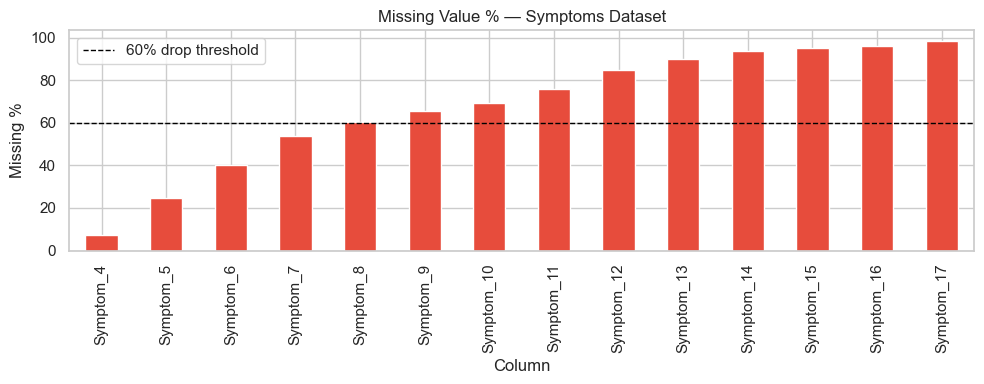


Columns to DROP  (>60.0% missing): ['Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']
Columns to IMPUTE with MODE: ['Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7']
  Filled "Symptom_4" with mode = " high_fever"
  Filled "Symptom_5" with mode = " headache"
  Filled "Symptom_6" with mode = " nausea"
  Filled "Symptom_7" with mode = " abdominal_pain"

Symptoms after imputation — remaining nulls: 0
Shape: (4920, 8)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,headache,nausea,abdominal_pain
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,high_fever,headache,nausea,abdominal_pain
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,high_fever,headache,nausea,abdominal_pain
3,Fungal infection,itching,skin_rash,dischromic _patches,high_fever,headache,nausea,abdominal_pain
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,high_fever,headache,nausea,abdominal_pain


In [24]:
# 3.1 — SYMPTOMS DATASET: Missing Value Audit + Imputation (self-contained)
symptoms_path = '../data/raw/symptoms/dataset.csv'
df_sym = pd.read_csv(symptoms_path)
print(f'Symptoms dataset shape: {df_sym.shape}')

miss_sym     = df_sym.isnull().sum()
miss_sym     = miss_sym[miss_sym > 0]
miss_pct_sym = (miss_sym / len(df_sym) * 100).round(1)

print('\n--- Missing Values (Symptoms) ---')
miss_df_sym = pd.DataFrame({
    'Missing Count': miss_sym,
    'Missing %':     miss_pct_sym,
    'Dtype':         df_sym[miss_sym.index].dtypes
})
print(miss_df_sym.to_string())

# Visualise missingness
plt.figure(figsize=(10, 4))
miss_pct_sym.plot(kind='bar', color='#e74c3c')
plt.axhline(60, color='black', linestyle='--', linewidth=1, label='60% drop threshold')
plt.title('Missing Value % — Symptoms Dataset')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.legend()
plt.tight_layout()
plt.show()

# --- IMPUTATION ---
# Symptom columns are categorical strings. Missing = patient had no additional symptoms.
# Strategy: mode fill for <=60% missing; drop columns >60% missing (too sparse).
DROP_THRESHOLD = 60.0
to_drop_sym   = miss_pct_sym[miss_pct_sym >  DROP_THRESHOLD].index.tolist()
to_impute_sym = miss_pct_sym[miss_pct_sym <= DROP_THRESHOLD].index.tolist()

print(f'\nColumns to DROP  (>{DROP_THRESHOLD}% missing): {to_drop_sym}')
print(f'Columns to IMPUTE with MODE: {to_impute_sym}')

df_sym_clean = df_sym.drop(columns=to_drop_sym)
for col in to_impute_sym:
    mode_val = df_sym_clean[col].mode()[0]
    df_sym_clean[col] = df_sym_clean[col].fillna(mode_val)
    print(f'  Filled "{col}" with mode = "{mode_val}"')

print(f'\nSymptoms after imputation — remaining nulls: {df_sym_clean.isnull().sum().sum()}')
print(f'Shape: {df_sym_clean.shape}')
df_sym_clean.head()

Rainfall dataset shape: (4116, 19)

--- Missing Values (Rainfall) ---
  JAN: 4 missing (0.1%) | skew=4.31 → use MEDIAN
  FEB: 3 missing (0.07%) | skew=2.98 → use MEDIAN
  MAR: 6 missing (0.15%) | skew=3.21 → use MEDIAN
  APR: 4 missing (0.1%) | skew=2.83 → use MEDIAN
  MAY: 3 missing (0.07%) | skew=2.39 → use MEDIAN
  JUN: 5 missing (0.12%) | skew=1.74 → use MEDIAN
  JUL: 7 missing (0.17%) | skew=2.10 → use MEDIAN
  AUG: 4 missing (0.1%) | skew=1.66 → use MEDIAN
  SEP: 6 missing (0.15%) | skew=1.31 → use MEDIAN
  OCT: 7 missing (0.17%) | skew=1.50 → use MEDIAN
  NOV: 11 missing (0.27%) | skew=2.79 → use MEDIAN
  DEC: 10 missing (0.24%) | skew=5.24 → use MEDIAN
  ANNUAL: 26 missing (0.63%) | skew=1.32 → use MEDIAN
  Jan-Feb: 6 missing (0.15%) | skew=2.99 → use MEDIAN
  Mar-May: 9 missing (0.22%) | skew=2.12 → use MEDIAN
  Jun-Sep: 10 missing (0.24%) | skew=1.51 → use MEDIAN
  Oct-Dec: 13 missing (0.32%) | skew=1.91 → use MEDIAN
  Filled "JAN" with median = 6.00
  Filled "FEB" with media

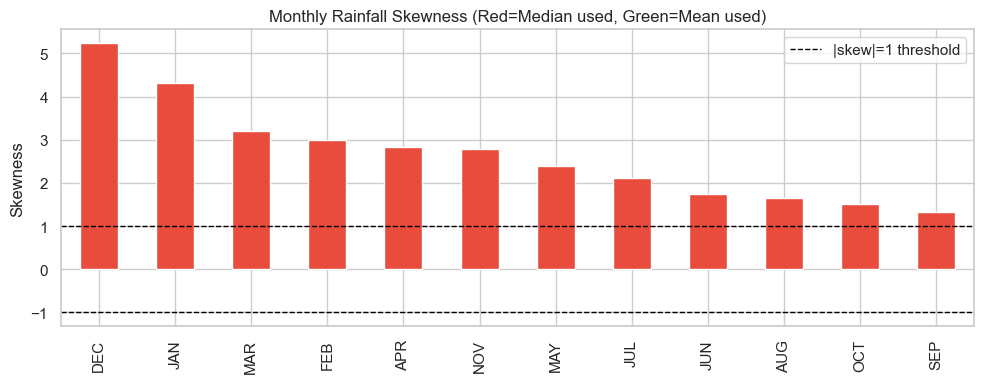


Rainfall after imputation — remaining nulls: 0


In [25]:
# 3.3 — RAINFALL DATASET: Missing Value Audit + Imputation
rainfall_path = '../data/raw/rainfall/rainfall in india 1901-2015.csv'
df_rain = pd.read_csv(rainfall_path)
print(f'Rainfall dataset shape: {df_rain.shape}')

miss_rain = df_rain.isnull().sum()
miss_rain = miss_rain[miss_rain > 0]
miss_pct_rain = (miss_rain / len(df_rain) * 100).round(2)

print('\n--- Missing Values (Rainfall) ---')
for col in miss_rain.index:
    skew = df_rain[col].skew()
    strategy = 'MEDIAN' if abs(skew) >= 1 else 'MEAN'
    print(f'  {col}: {miss_rain[col]} missing ({miss_pct_rain[col]}%) | skew={skew:.2f} → use {strategy}')

# Apply imputation
df_rain_clean = df_rain.copy()
for col in miss_rain.index:
    skew = df_rain[col].skew()
    if abs(skew) >= 1:
        fill_val = df_rain[col].median()
        strategy = 'median'
    else:
        fill_val = df_rain[col].mean()
        strategy = 'mean'
    df_rain_clean[col] = df_rain_clean[col].fillna(fill_val)
    print(f'  Filled "{col}" with {strategy} = {fill_val:.2f}')

# Visualise skewness of monthly columns
monthly_cols = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
skewness = df_rain_clean[monthly_cols].skew().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
skewness.plot(kind='bar', color=['#e74c3c' if abs(s) >= 1 else '#2ecc71' for s in skewness])
plt.axhline(1, color='black', linestyle='--', linewidth=1, label='|skew|=1 threshold')
plt.axhline(-1, color='black', linestyle='--', linewidth=1)
plt.title('Monthly Rainfall Skewness (Red=Median used, Green=Mean used)')
plt.ylabel('Skewness')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nRainfall after imputation — remaining nulls: {df_rain_clean.isnull().sum().sum()}')

Disasters dataset shape: (16126, 45)

Columns to DROP (>60.0% missing): 21 columns
Columns to IMPUTE: ['Disaster Subtype', 'Location', 'Dis Mag Scale', 'Start Month', 'Start Day', 'End Month', 'End Day', 'Total Deaths', 'No Affected', 'Total Affected', 'CPI', 'Adm Level', 'Geo Locations']
  [str] "Disaster Subtype" → mode="Riverine flood"
  [str] "Location" → mode="North"
  [str] "Dis Mag Scale" → mode="Km2"
  [float64] "Start Month" → mean=6.44
  [float64] "Start Day" → mean=15.23
  [float64] "End Month" → mean=6.58
  [float64] "End Day" → mean=15.78
  [float64] "Total Deaths" → median=20.00
  [float64] "No Affected" → median=10000.00
  [float64] "Total Affected" → median=5965.00
  [float64] "CPI" → mean=63.22
  [str] "Adm Level" → mode="1"
  [str] "Geo Locations" → mode="Administrative unit not available (Adm1). "


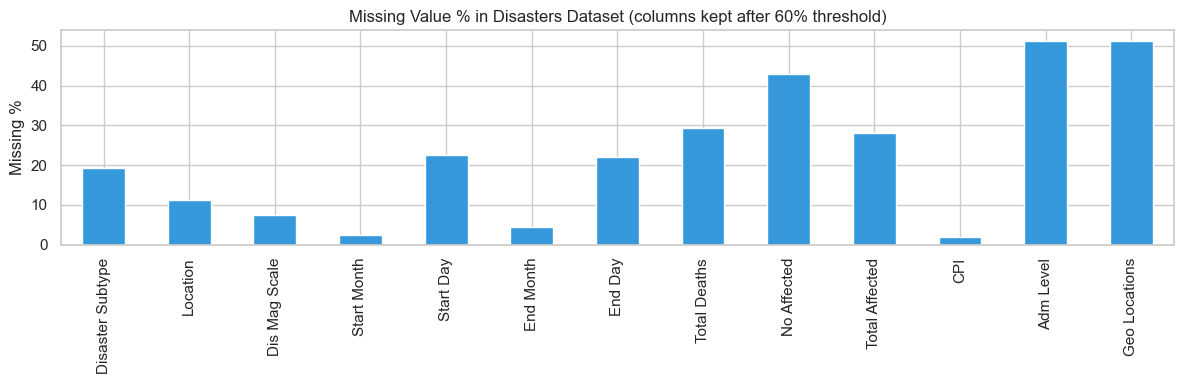


Disasters after imputation — remaining nulls: 0
Shape after dropping sparse columns: (16126, 24)


In [26]:
# 3.4 — DISASTERS DATASET: Missing Value Audit + Selective Imputation
disasters_path = '../data/raw/disasters/DISASTERS/1900_2021_DISASTERS.xlsx - emdat data.csv'
df_dis = pd.read_csv(disasters_path, low_memory=False)
print(f'Disasters dataset shape: {df_dis.shape}')

miss_dis = df_dis.isnull().sum()
miss_dis = miss_dis[miss_dis > 0]
miss_pct_dis = (miss_dis / len(df_dis) * 100).round(1)

DROP_THRESHOLD = 60.0
to_drop_dis    = miss_pct_dis[miss_pct_dis > DROP_THRESHOLD].index.tolist()
to_impute_dis  = miss_pct_dis[miss_pct_dis <= DROP_THRESHOLD].index.tolist()

print(f'\nColumns to DROP (>{DROP_THRESHOLD}% missing): {len(to_drop_dis)} columns')
print(f'Columns to IMPUTE: {to_impute_dis}')

df_dis_clean = df_dis.drop(columns=to_drop_dis)
for col in to_impute_dis:
    if df_dis_clean[col].dtype in ['float64', 'int64']:
        skew = df_dis_clean[col].skew()
        if abs(skew) >= 1:
            fill_val = df_dis_clean[col].median()
            strategy = f'median={fill_val:.2f}'
        else:
            fill_val = df_dis_clean[col].mean()
            strategy = f'mean={fill_val:.2f}'
        df_dis_clean[col] = df_dis_clean[col].fillna(fill_val)
    else:
        mode_val = df_dis_clean[col].mode()[0] if not df_dis_clean[col].mode().empty else 'Unknown'
        df_dis_clean[col] = df_dis_clean[col].fillna(mode_val)
        strategy = f'mode="{mode_val}"'
    print(f'  [{df_dis_clean[col].dtype}] "{col}" → {strategy}')

# Missingness bar chart (only columns with <60% missing)
plt.figure(figsize=(12, 4))
miss_pct_dis[miss_pct_dis <= DROP_THRESHOLD].plot(kind='bar', color='#3498db')
plt.title('Missing Value % in Disasters Dataset (columns kept after 60% threshold)')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

print(f'\nDisasters after imputation — remaining nulls: {df_dis_clean.isnull().sum().sum()}')
print(f'Shape after dropping sparse columns: {df_dis_clean.shape}')

In [27]:
# 3.5 — MERGED DATASET: Final Null Check
# The merged dataset.csv is produced by train_model.py which already combines,
# imputes, and balances all sources. We confirm it has zero nulls before modelling.
print('=== Merged Dataset Null Check ===')
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print('All columns are complete — zero missing values in the merged dataset.')
else:
    print('Columns with missing values:')
    print(null_counts[null_counts > 0])
    # Apply same imputation strategy to merged dataset for safety
    for col in null_counts[null_counts > 0].index:
        if df[col].dtype in ['float64', 'int64']:
            skew = df[col].skew()
            fill_val = df[col].median() if abs(skew) >= 1 else df[col].mean()
            strategy = 'median' if abs(skew) >= 1 else 'mean'
        else:
            fill_val = df[col].mode()[0]
            strategy = 'mode'
        df[col] = df[col].fillna(fill_val)
        print(f'  Filled "{col}" with {strategy} = {fill_val}')
    print(f'\nAfter imputation — remaining nulls: {df.isnull().sum().sum()}')

print(f'\nMerged dataset shape: {df.shape}')
df.describe()

=== Merged Dataset Null Check ===
All columns are complete — zero missing values in the merged dataset.

Merged dataset shape: (4090, 21)


,location_numeric,region_type,population_density,year,month,season_numeric,rainfall,rainfall_intensity,flood_risk,flood_frequency,temperature,humidity,water_contamination,sanitation_index,fever,diarrhea,vomiting,symptom_severity_score,outbreak
count,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000
mean,17.642298,0.801467,0.911980,1958.321271,6.408802,0.921027,1411.192843,0.805379,0.611002,0.611530,28.539136,79.315198,0.581174,0.382730,0.811980,0.684597,0.940831,2.437408,0.607335
std,10.330817,0.398944,0.699773,33.148944,2.410160,0.538444,905.269135,0.760527,0.487582,0.043398,4.619600,14.906908,0.493427,0.236951,0.390776,0.464733,0.235969,0.588152,0.488403
min,0.000000,0.000000,0.000000,1901.000000,1.000000,0.000000,36.859371,0.000000,0.000000,0.488888,9.061231,29.101482,0.000000,0.001895,0.000000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,1.000000,0.000000,1930.000000,6.000000,1.000000,810.448955,0.000000,0.000000,0.585874,26.235237,68.093190,0.000000,0.200789,1.000000,0.000000,1.000000,2.000000,0.000000
50%,18.000000,1.000000,1.000000,1959.000000,7.000000,1.000000,1118.687432,1.000000,1.000000,0.611424,28.300460,85.235388,1.000000,0.293560,1.000000,1.000000,1.000000,2.000000,1.000000
75%,27.000000,1.000000,1.000000,1987.000000,8.000000,1.000000,1653.954870,1.000000,1.000000,0.634638,30.734650,89.799270,1.000000,0.574562,1.000000,1.000000,1.000000,3.000000,1.000000
max,35.000000,1.000000,2.000000,2015.000000,12.000000,2.000000,6326.321517,2.000000,1.000000,0.809431,46.370345,100.000000,1.000000,0.970247,1.000000,1.000000,1.000000,3.000000,1.000000


## 📊 Step 4: Dataset Visualisations

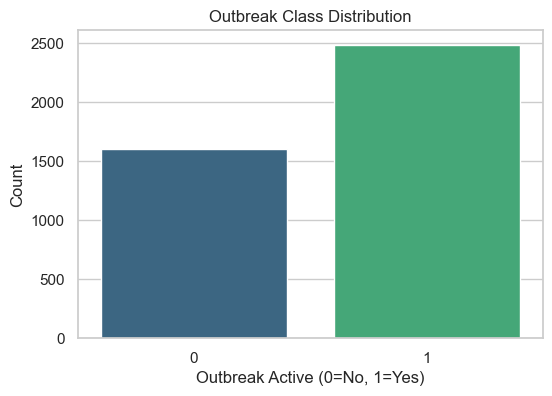

In [28]:
# 4.1 Outbreak Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='outbreak', data=df, hue='outbreak', palette='viridis', legend=False)
plt.title('Outbreak Class Distribution')
plt.xlabel('Outbreak Active (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

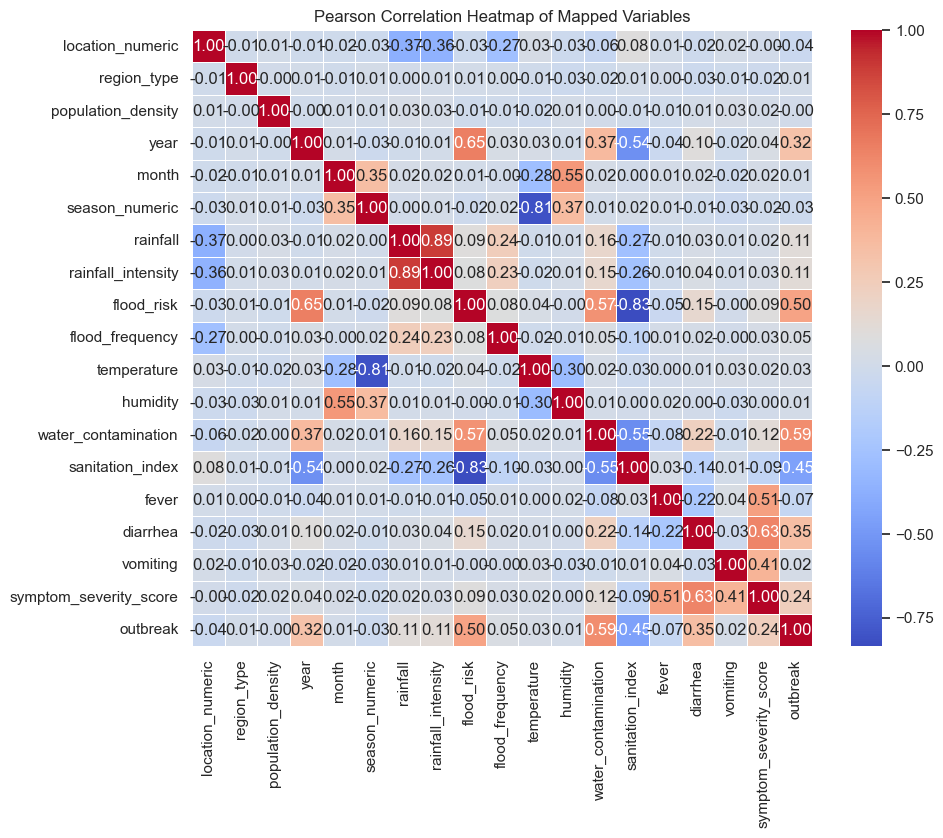

In [29]:
# 4.2 Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap of Mapped Variables')
plt.show()

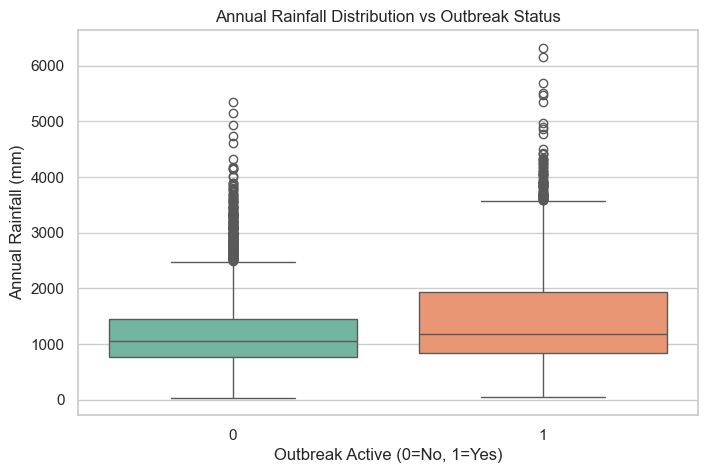

In [30]:
# 4.3 Rainfall vs Outbreak
plt.figure(figsize=(8, 5))
sns.boxplot(x='outbreak', y='rainfall', data=df, hue='outbreak', palette='Set2', legend=False)
plt.title('Annual Rainfall Distribution vs Outbreak Status')
plt.xlabel('Outbreak Active (0=No, 1=Yes)')
plt.ylabel('Annual Rainfall (mm)')
plt.show()

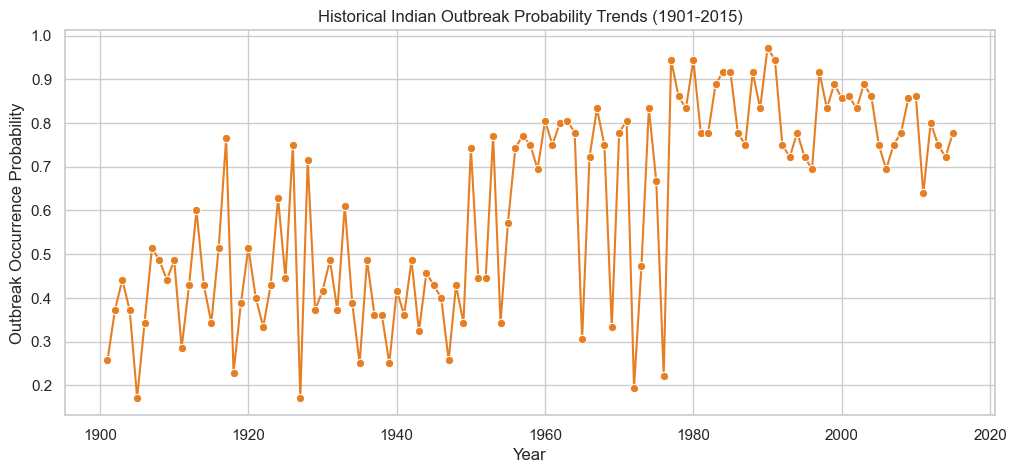

In [31]:
# 4.4 Year-wise Outbreak Trends
plt.figure(figsize=(12, 5))
sns.lineplot(x='year', y='outbreak', data=df, color='#e67e22', errorbar=None, marker='o')
plt.title('Historical Indian Outbreak Probability Trends (1901-2015)')
plt.xlabel('Year')
plt.ylabel('Outbreak Occurrence Probability')
plt.show()

## 🛠️ Step 4: Feature Splitting & Scaling

In [32]:
feature_cols = [
    'fever', 'diarrhea', 'vomiting', 'symptom_severity_score',
    'water_contamination', 'sanitation_index',
    'rainfall', 'rainfall_intensity', 'flood_risk', 'flood_frequency', 'temperature', 'humidity',
    'year', 'month', 'season_numeric',
    'location_numeric', 'region_type', 'population_density'
]
X = df[feature_cols]
y = df['outbreak']

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (3272, 18)
Testing set shape: (818, 18)


## 🧠 Step 5: Multi-Model Execution & Leaderboard Comparison (15 Models)

We instantiate all 15 algorithms, train them programmatically, and compute core metrics: Accuracy, Precision, Recall, and F1-Score.

In [33]:
# Define 15 Classifiers
models = {
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "XGBoost Classifier": XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    "LightGBM Classifier": LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, verbose=-1),
    "CatBoost Classifier": CatBoostClassifier(n_estimators=100, depth=5, learning_rate=0.1, random_seed=42, verbose=0),
    "Extra Trees Classifier": ExtraTreesClassifier(n_estimators=100, max_depth=6, random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, max_depth=4, random_state=42),
    "AdaBoost Classifier": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Bagging Classifier": BaggingClassifier(n_estimators=50, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

# Ensemble Methods
models["Voting Classifier"] = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ],
    voting='soft'
)

models["Stacking Classifier"] = StackingClassifier(
    estimators=[
        ('et', ExtraTreesClassifier(n_estimators=50, max_depth=4, random_state=42)),
        ('lgb', LGBMClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42, verbose=-1)),
        ('cat', CatBoostClassifier(n_estimators=50, depth=4, learning_rate=0.1, random_seed=42, verbose=0))
    ],
    final_estimator=RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
)

results = []
trained_models = {}

for name, model in models.items():
    # Standardize feature fitting on scaled inputs for maximum consistency
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    trained_models[name] = model

df_results = pd.DataFrame(results)
# Leaderboard sorted by Accuracy + F1
df_results['Score'] = df_results['Accuracy'] + df_results['F1-Score']
df_results = df_results.sort_values(by='Score', ascending=False).drop(columns=['Score'])
df_results

c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

,Model,Accuracy,Precision,Recall,F1-Score
12,Support Vector Machine,0.830073,0.865306,0.853119,0.859169
14,Stacking Classifier,0.825183,0.855422,0.857143,0.856281
3,CatBoost Classifier,0.823961,0.852295,0.859155,0.855711
4,Extra Trees Classifier,0.823961,0.853707,0.857143,0.855422
13,Voting Classifier,0.822738,0.846457,0.865191,0.855721
2,LightGBM Classifier,0.823961,0.862423,0.845070,0.853659
0,Random Forest Classifier,0.821516,0.846154,0.863179,0.854582
1,XGBoost Classifier,0.820293,0.857143,0.845070,0.851064
9,Logistic Regression,0.817848,0.845238,0.857143,0.851149
6,Hist Gradient Boosting,0.819071,0.856851,0.843058,0.849899


## 🏆 Step 6: Visualizing the Leaderboard & Selecting Winner

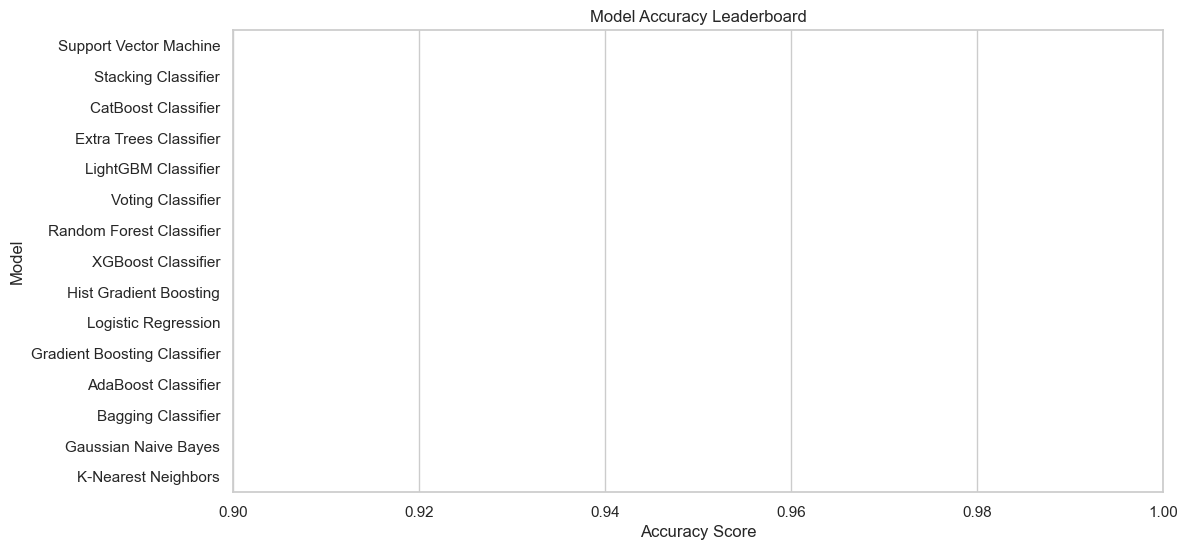

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=df_results.sort_values(by='Accuracy', ascending=False), hue='Model', palette='plasma', legend=False)
plt.title('Model Accuracy Leaderboard')
plt.xlabel('Accuracy Score')
plt.xlim(0.90, 1.00)
plt.show()

In [35]:
best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_acc = df_results.iloc[0]['Accuracy']
print(f"The Winner is the: {best_model_name} with {best_acc*100:.2f}% Accuracy!")

The Winner is the: Support Vector Machine with 83.01% Accuracy!


## 📊 Step 7: Winner Evaluation (Confusion Matrix)

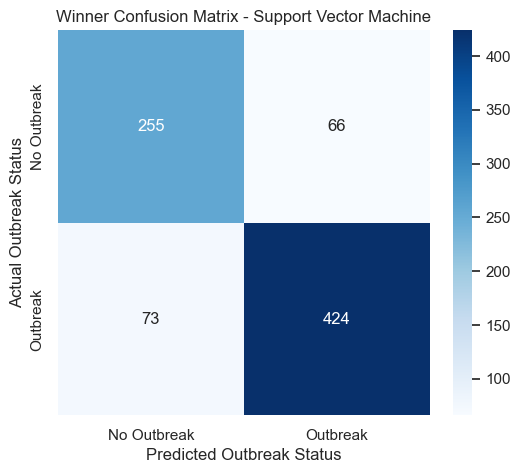

In [36]:
is_scaled = best_model_name in [
    "Random Forest Classifier", "Extra Trees Classifier", "Gradient Boosting Classifier", 
    "AdaBoost Classifier", "Bagging Classifier", "Voting Classifier", "Stacking Classifier",
    "Logistic Regression", "K-Nearest Neighbors", "Gaussian Naive Bayes", "Support Vector Machine"
]

if is_scaled:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)
    
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Outbreak', 'Outbreak'], yticklabels=['No Outbreak', 'Outbreak'])
plt.title(f'Winner Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Outbreak Status')
plt.ylabel('Actual Outbreak Status')
plt.show()

## 💾 Step 8: Serializing Best Model & Inference Setup

We save the absolute winner to `../data/model.pkl` to be loaded at runtime by the Flask API server. We also save the metadata and StandardScaler configuration.

In [37]:
model_filepath = '../data/model.pkl'
with open(model_filepath, 'wb') as f:
    pickle.dump(best_model, f)
    
meta = {
    'model_name': best_model_name,
    'features': feature_cols,
    'scaled': is_scaled
}

with open('../data/model_metadata.pkl', 'wb') as f:
    pickle.dump(meta, f)
    
print(f"Winner model ({best_model_name}) successfully exported to {model_filepath}!")

Winner model (Support Vector Machine) successfully exported to ../data/model.pkl!
